# Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import time
import sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler  # or MinMaxScaler
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator, ScalarFormatter)  
from matplotlib.ticker import FuncFormatter
from joblib import dump, load
from matplotlib import rc

# Data pre-processing

In [2]:
# Create a master smiles map containing the 3 maps
smiles_maps = ["poly", "repeat", "monomer"]
similarity_methods = ["morgan", "rdkit_path", "maccs", "rdkit_physchem", "mordred"]
output = 'gisaxs_domain'

In [3]:
# Create a loop that stores each data set into a dictionary
data_directory = '../../pre-processing/likeness_data/'
df_likeness = {}
for name in smiles_maps:
    for method in similarity_methods:
        # Continuous descriptor methods cannot handle the wildcard present in the 'poly' SMILES
        if "poly" in name.lower() and method in ["rdkit_physchem", "mordred"]:
            continue
        # Create temporary copy of each df
        file_path = f"{data_directory}{name}_{method}.xlsx"
        temp_df = pd.read_excel(file_path)

        # Store each df into a dictionary for access later
        df_likeness_key = f"{name}_{method}"
        df_likeness[df_likeness_key] = temp_df

# Load models

In [4]:
best_models = {}
for name in smiles_maps:
    for method in similarity_methods:
        # Continuous descriptor methods cannot handle the wildcard present in the 'poly' SMILES
        if "poly" in name.lower() and method in ["rdkit_physchem", "mordred"]:
            continue
                
        # Store each df into a dictionary for access later
        df_likeness_key = f"{name}_{method}"        
        # dump(best_models[df_likeness_key] , f'{output}_{df_likeness_key}.joblib')
        best_models[df_likeness_key] = load(f'raw_models/bayesian/domain/scaled_{output}_{df_likeness_key}.joblib')

# Visualize the results

# Parity

In [5]:
# Identify BCP categories
def classify(df):
    # Get min and max values for each condition column
    min_AA, max_AA = df['comp1_blockA_type_comp2_blockA_type_exists'].min(), df['comp1_blockA_type_comp2_blockA_type_exists'].max()
    min_AB, max_AB = df['comp1_blockA_type_comp2_blockB_type_exists'].min(), df['comp1_blockA_type_comp2_blockB_type_exists'].max()
    min_BB, max_BB = df['comp2_blockA_type_comp2_blockB_type_exists'].min(), df['comp2_blockA_type_comp2_blockB_type_exists'].max()
    
    cond_AA = df['comp1_blockA_type_comp2_blockA_type_exists']
    cond_AB = df['comp1_blockA_type_comp2_blockB_type_exists']
    cond_BB = df['comp2_blockA_type_comp2_blockB_type_exists']
    
    types = np.full(len(df), 'BCP', dtype=object)
    types[(cond_AA == max_AA) & (cond_BB == min_BB)] = 'BCP+HP'
    types[(cond_AB == max_AB)] = 'BCP+BCP'
    return types

# With the cool density profiles
def plot_pred_vs_actual(X_train, X_test, method, y_train, y_train_pred, y_test, y_test_pred, 
                        test_r2, model_output, output_path=None):

    errors = y_test_pred - y_test
    # Metrics
    me = np.mean(errors)
    mae = np.mean(np.abs(errors))
    mape = np.mean(np.abs(errors / y_test)) * 100
    r2 = 1 - np.sum(errors**2) / np.sum((y_test - np.mean(y_test))**2)
    
    # Configure figure aesthetics
    %matplotlib inline
    rc('text', usetex=False)
    rc('mathtext', fontset='cm')
    rc('xtick', labelsize=25)   
    rc('xtick.major', size=7)  
    rc('xtick.minor', size=4)
    rc('xtick.major', width=2)
    rc('xtick.minor', width=2)
    rc('ytick.major', width=2)
    rc('ytick.minor', width=2)
    rc('ytick', labelsize=25)
    rc('ytick.major', size=7)
    rc('ytick.minor', size=4)
    rc('axes', labelsize=25) 
    rc('axes', linewidth=2) 
    rc('font',family='sans serif')
    rc('font', style='normal')
    rc('font', weight='500')
    rc('font', size='15')
    rc('axes', labelweight='500')
    rc('axes.spines', **{'right':True, 'top':True}) 
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True

    fig = plt.figure(figsize=(8, 8))
    gs = fig.add_gridspec(2, 2, width_ratios=[7, 2], height_ratios=[2, 7],
                          hspace=-0.015, wspace=-0.0125)

    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    # Plot perfect prediction line
    lims = [min(y_train.min()*10, y_test.min()*10), max(y_train.max()*10, y_test.max()*10)]
    # Add a proportional buffer
    buffer = 0.5 * (lims[1] - lims[0])
    lims = [lims[0] - buffer, lims[1] + buffer]
    ax_main.plot(lims, lims, '--', color='red', zorder=0)

    train_types = classify(X_train)
    test_types = classify(X_test)
    
    # Combine datasets
    X_all = X_test
    y_all = y_test
    y_all_pred = y_test_pred
    
    # Classify and color by composition type
    types_all = classify(X_all)
    colors = {'BCP': 'indigo', 'BCP+HP': 'dodgerblue', 'BCP+BCP': 'forestgreen'}
    
    # Scatter points colored by composition type
    for label, color in colors.items():
        mask = types_all == label
        ax_main.scatter(
            y_all[mask]*10,
            y_all_pred[mask]*10,
            color=color,
            edgecolors='black',
            alpha=0.75,
            s=100,
            label=label
        )

    # Density along X (Actual) - use the scaled axis range
    for label, color in colors.items():
        vals = y_all[types_all == label] * 10  # scale to match axis
        if len(vals) > 1:
            kde = gaussian_kde(vals)
            x_grid = np.linspace(175, 900, 200)  # match ax_main.set_xlim
            ax_top.plot(x_grid, kde(x_grid), color=color, alpha=0.95, lw=1)
            ax_top.fill_between(x_grid, 0, kde(x_grid), color=color, alpha=0.5)
    
    # Density along Y (Predicted) - use the scaled axis range
    for label, color in colors.items():
        vals = y_all_pred[types_all == label] * 10  # scale to match axis
        if len(vals) > 1:
            kde = gaussian_kde(vals)
            y_grid = np.linspace(175, 900, 200)  # match ax_main.set_ylim
            ax_right.plot(kde(y_grid), y_grid, color=color, alpha=0.95, lw=1)
            ax_right.fill_betweenx(y_grid, 0, kde(y_grid), color=color, alpha=0.5)

    # Aesthetic adjustments
    # ax.set_xlim(17.5,90) # True labels
    # ax.set_ylim(17.5,90)
    ax_main.set_xlim(175,900) #Adjusted for plotting consistency with FWHM plots
    ax_main.set_ylim(175,900)
    ax_main.xaxis.set_major_locator(MultipleLocator(200))
    ax_main.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax_main.yaxis.set_major_locator(MultipleLocator(200))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(2))

    # --- Scientific notation formatter ---
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_scientific(True)
    sci_formatter.set_powerlimits((1, 1))  # Force sci notation for all values
    sci_formatter.orderOfMagnitude = 1  # Force ×10⁻³

    ax_main.xaxis.set_major_formatter(sci_formatter)
    ax_main.yaxis.set_major_formatter(sci_formatter)
    ax_main.xaxis.offsetText.set_color('white')  # sci notation exponent label
    ax_main.yaxis.offsetText.set_color('white')  # sci notation exponent label

    # After your formatter block, add:
    fig.canvas.draw()
    offset_x = ax_main.xaxis.get_offset_text()
    # offset_x.set_horizontalalignment('right')
    offset_x.set_position((1.05, 0))
    offset_x.set_fontsize(20)  # adjust as needed
    
    offset_y = ax_main.yaxis.get_offset_text()
    # offset_y.set_horizontalalignment('left')
    offset_y.set_position((-0.175, 0.0))
    offset_y.set_fontsize(20)
    
    ax_main.set_xlabel('Actual \n domain spacing (nm)', fontsize=30)
    ax_main.set_ylabel('Predicted \n domain spacing (nm)', fontsize=30, labelpad=0)
    ax_main.tick_params(axis='both', which='both', reset=True, top=False, right=False)
    ax_main.set_facecolor('white')
    ax_main.grid(False)

    # Hide density axis ticks
    ax_top.axis('off')
    ax_right.axis('off')

    # Legend
    legend = ax_main.legend(fontsize=20, markerscale=1.5, frameon=False, loc='upper left')
    legend.get_frame().set_facecolor('white')

    # Error metric text
    ax_main.text(
        0.475, 0.2, 
        rf'R$^2$ = {r2:.3f}' '\n'
        rf'MAE = {mae:.2f} nm' '\n'
        rf'MAPE = {mape:.2f} %', 
        transform=ax_main.transAxes,
        fontsize=20, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0))

    # Axes borders
    for ax in [ax_main, ax_top, ax_right]:
        for spine in ax.spines.values():
            spine.set_color('black')    
    # Save figure
    if output_path:
        # plt.savefig(f"{output_path}{model_output}_parity.pdf", format='pdf', bbox_inches='tight', pad_inches=0.05,
        #            transparent=False)
        plt.savefig(f"{output_path}{model_output}_parity.pdf", format='pdf', bbox_inches='tight', pad_inches=0.05,
                   transparent=True)


Model trained on: poly_morgan
Training r2: 0.9966288590071984, training mae: 0.2846928751065768
Testing r2: 0.9844598427514014, testing mae: 0.8013210950734119

Model trained on: poly_rdkit_path
Training r2: 0.9967690027195625, training mae: 0.28452369365248203
Testing r2: 0.9850857287503814, testing mae: 0.7762402290229166

Model trained on: poly_maccs
Training r2: 0.9970190554744879, training mae: 0.27282325693995396
Testing r2: 0.9863351427775933, testing mae: 0.7759012556946596

Model trained on: repeat_morgan
Training r2: 0.9967397772914213, training mae: 0.2792556557207092
Testing r2: 0.9846288631140746, testing mae: 0.8065245191013166

Model trained on: repeat_rdkit_path
Training r2: 0.9968268455265672, training mae: 0.2841362978221225
Testing r2: 0.9850277027315254, testing mae: 0.7736480776736409

Model trained on: repeat_maccs
Training r2: 0.9969105348295982, training mae: 0.27345614365361587
Testing r2: 0.9849496239434229, testing mae: 0.7755712313207667

Model trained on: 

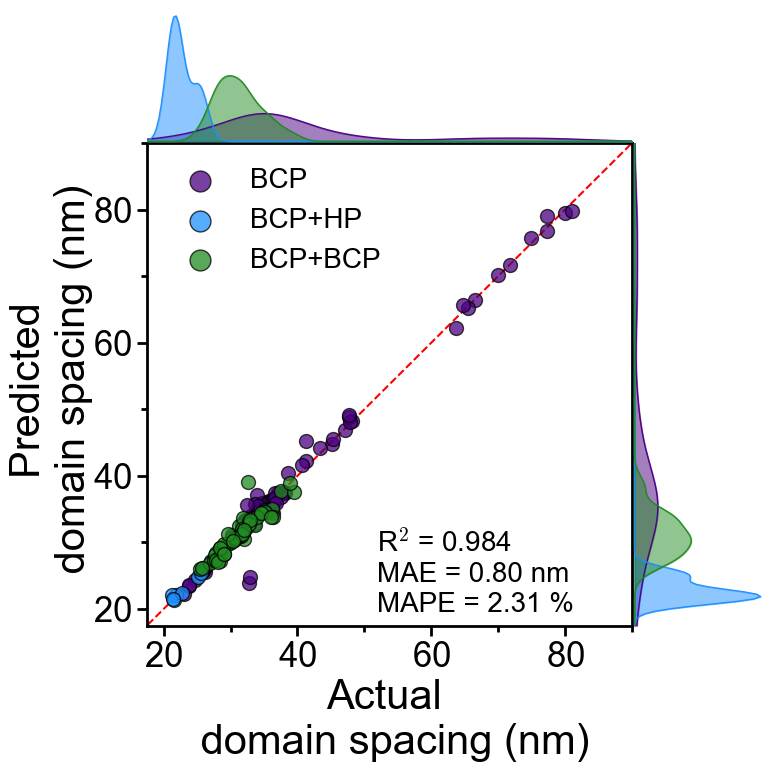

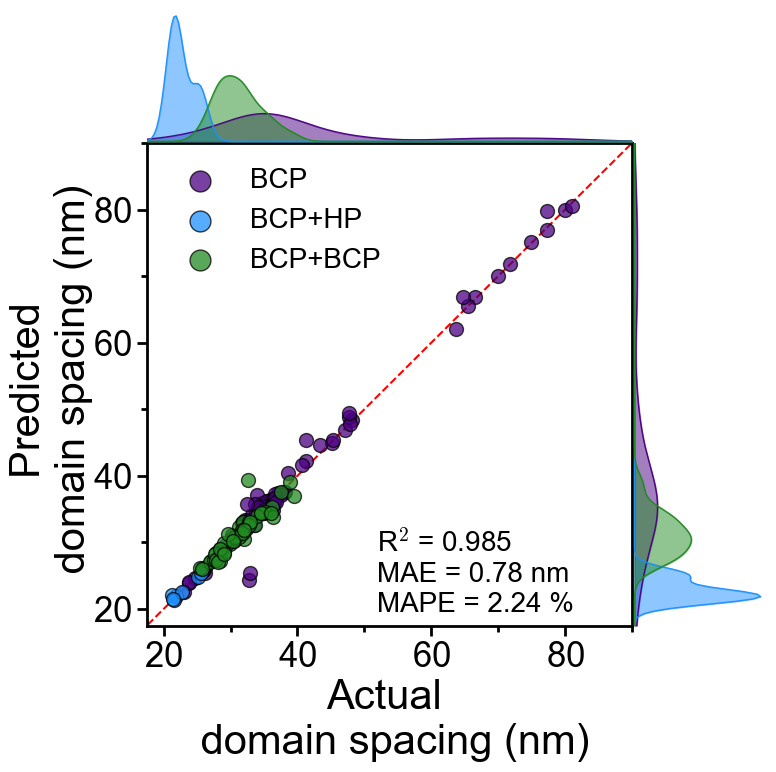

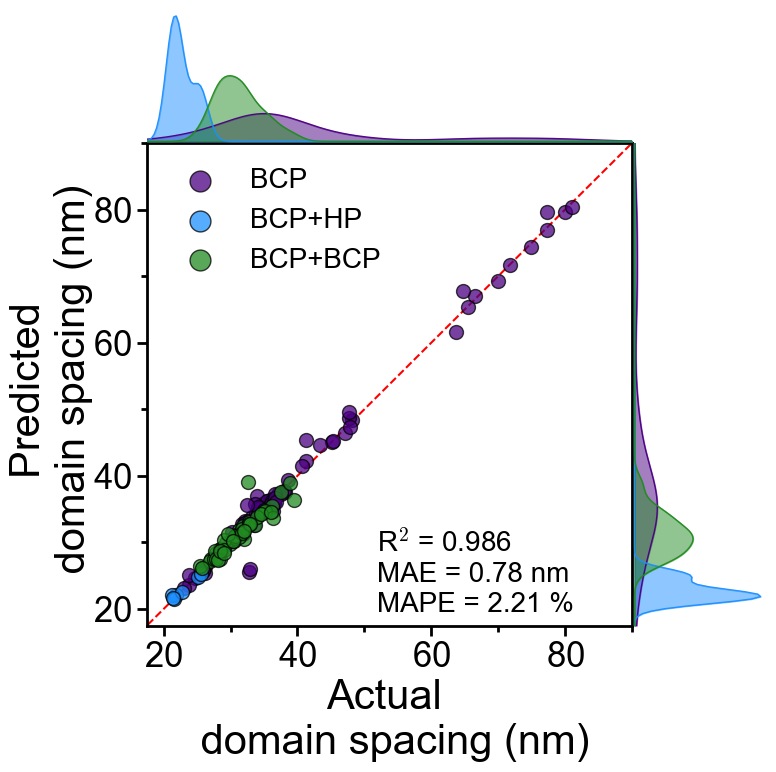

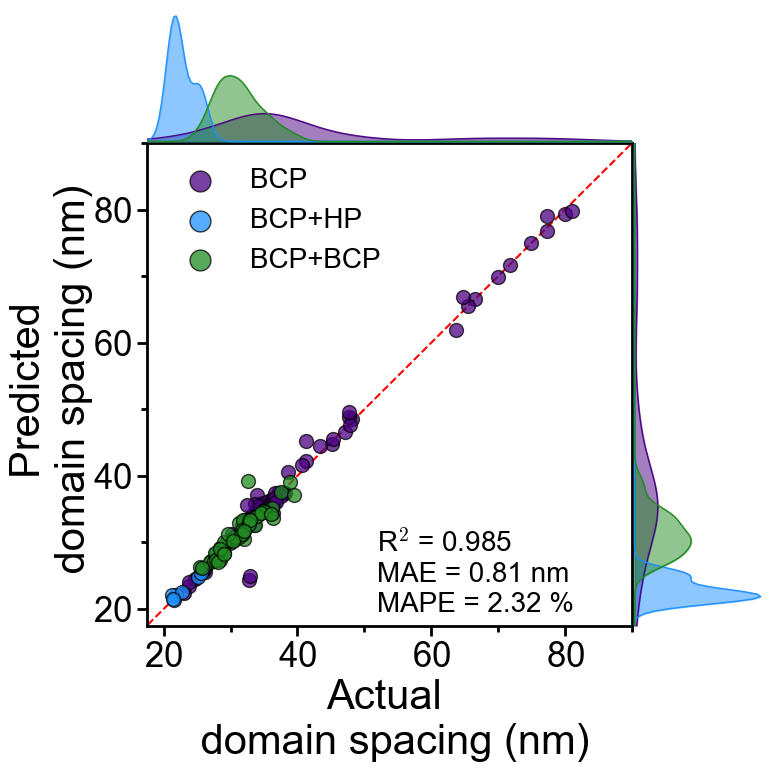

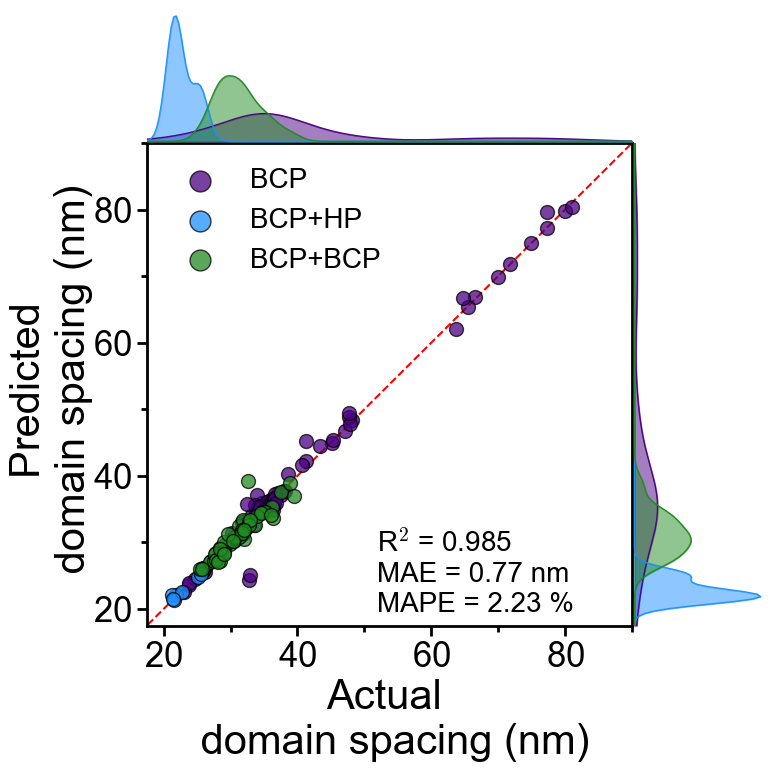

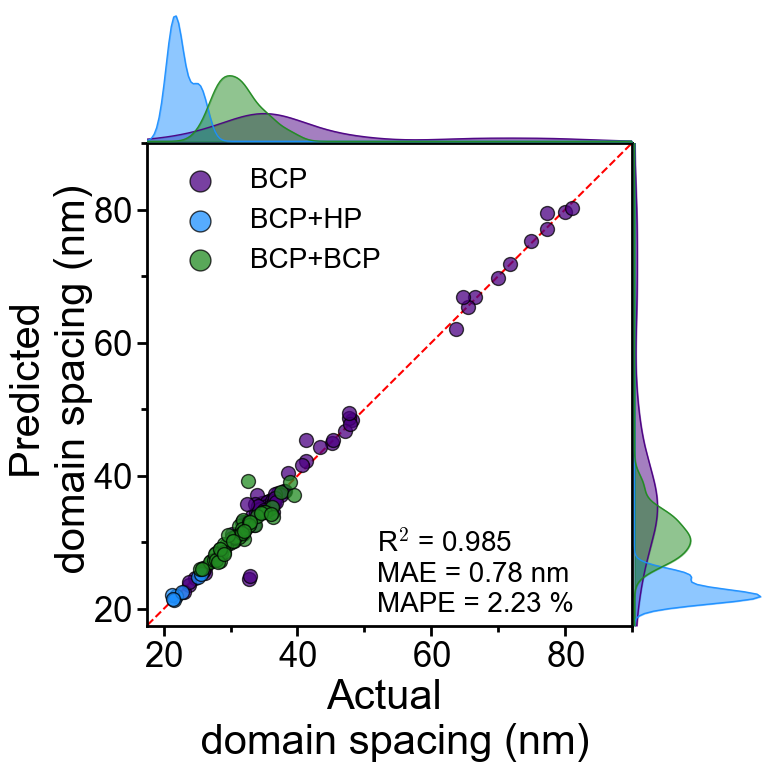

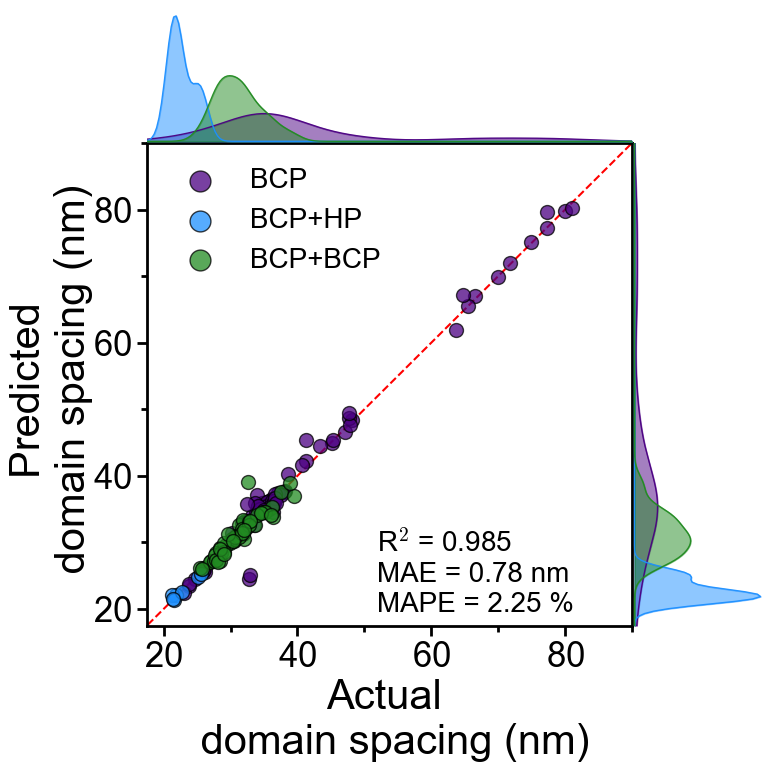

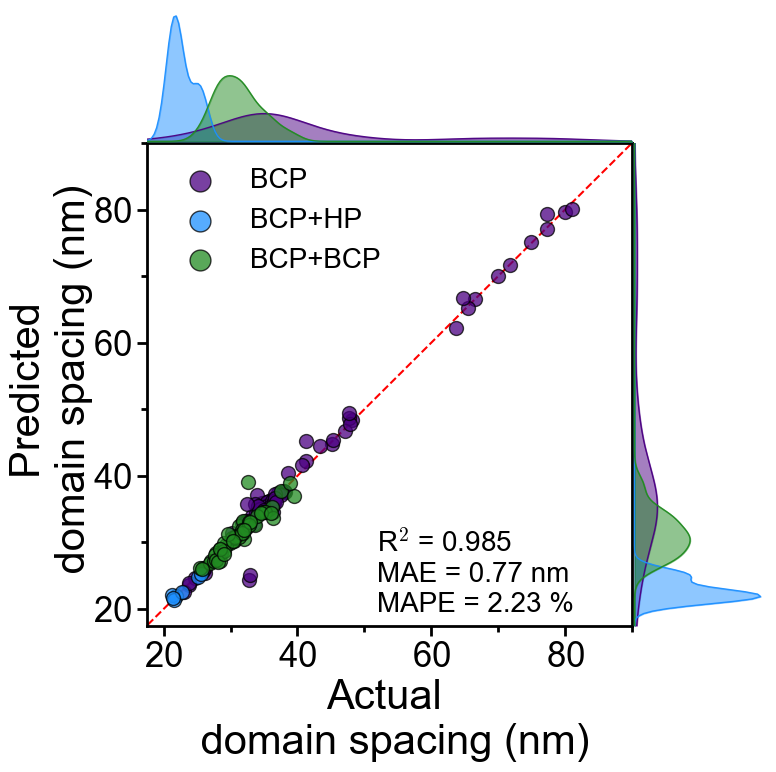

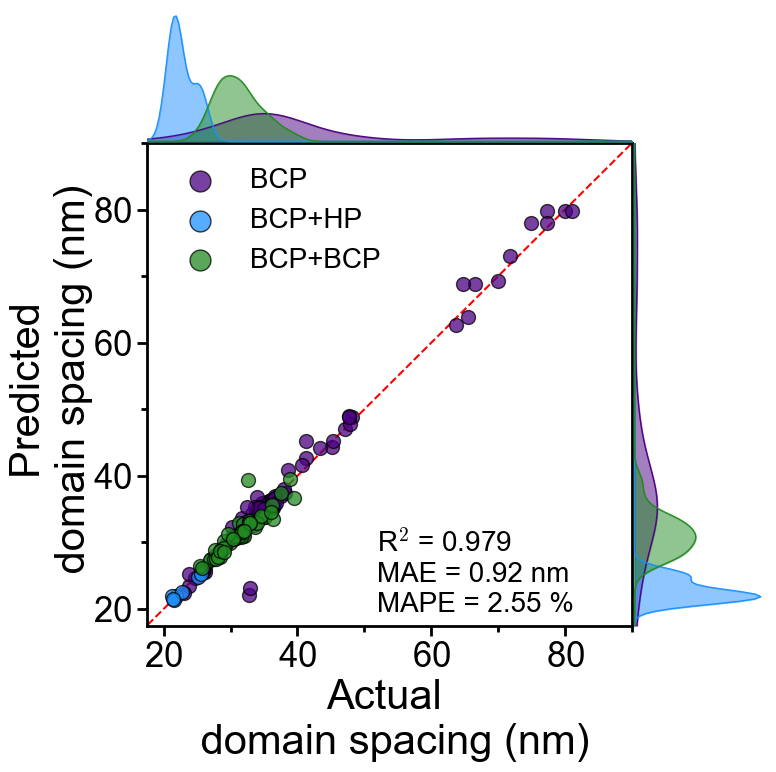

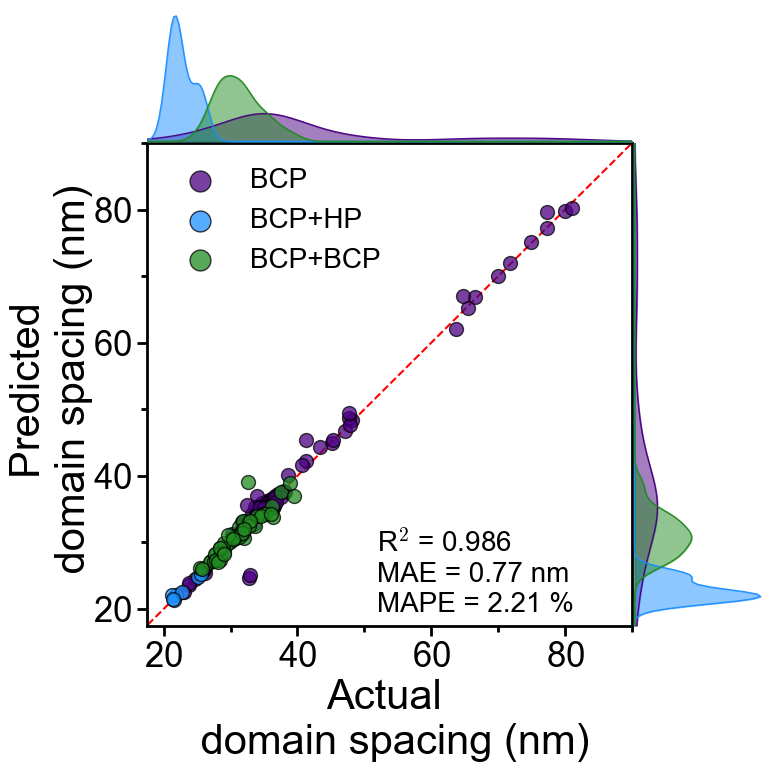

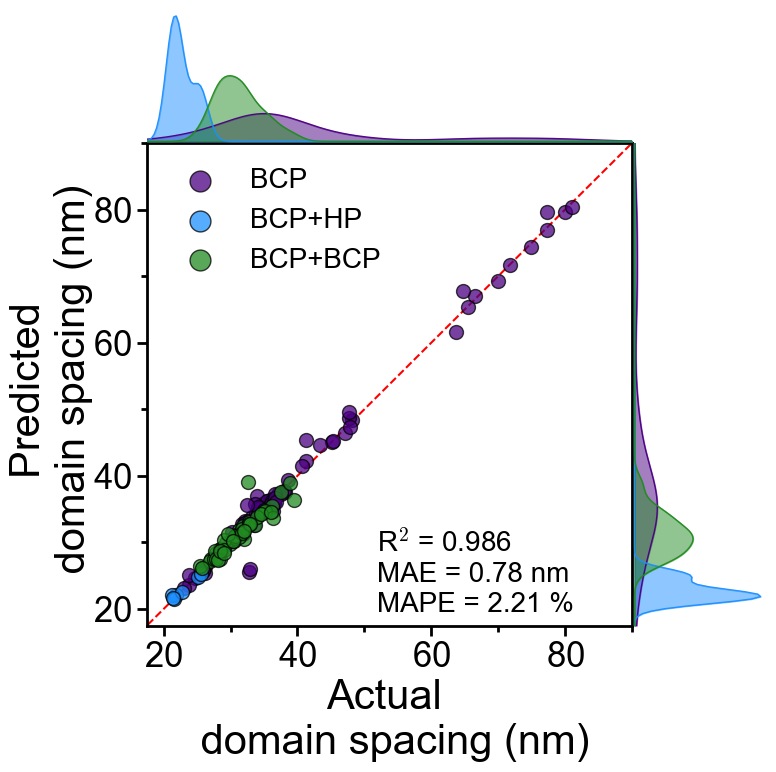

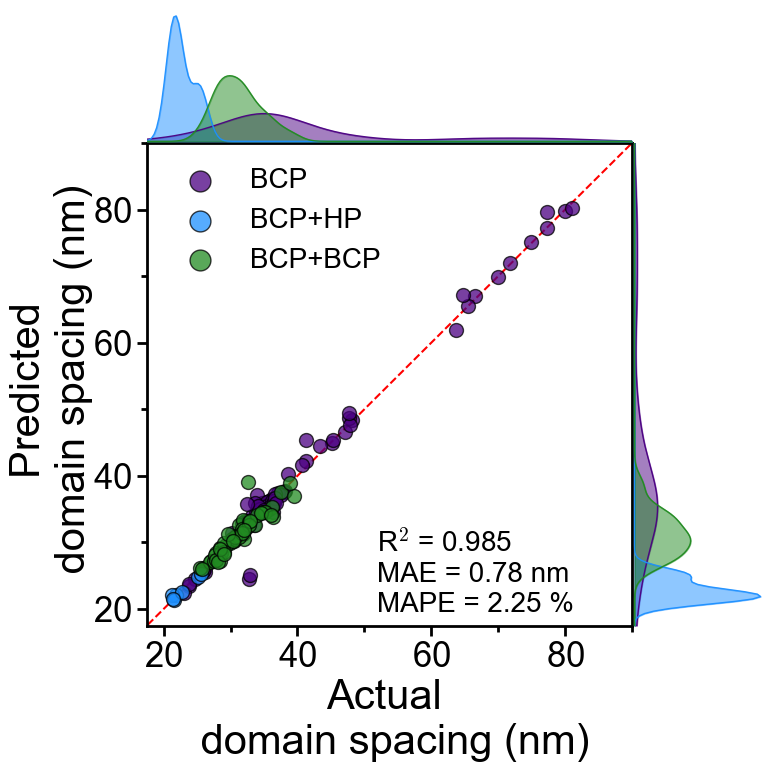

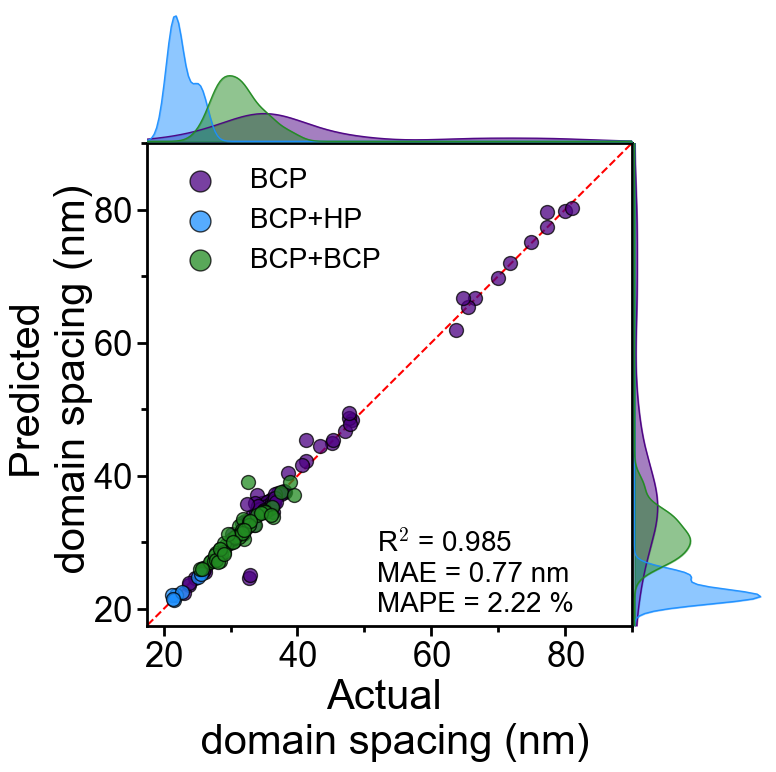

In [6]:
for name in smiles_maps:
    for method in similarity_methods:
        # Continuous descriptor methods cannot handle the wildcard present in the 'poly' SMILES
        if "poly" in name.lower() and method in ["rdkit_physchem", "mordred"]:
            continue
        
        df_likeness_key = f"{name}_{method}"
        df = df_likeness[df_likeness_key]
        # Drop rows with missing data
        df_clean = df.dropna()
        
        # Assign input variables and target variable
        inputs = df_clean.iloc[:, 1:-2].copy()
        target = df_clean[f'{output}']
        
        # Split the data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            inputs, target, test_size=0.2, random_state=10
        )
        
        # Scale the inputs (fit only on training data to avoid data leakage)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
        X_test_scaled = scaler.transform(X_test)
        X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

        temp_model = best_models[df_likeness_key]
        
        print(f'\nModel trained on: {df_likeness_key}')
        
        train_r2 = temp_model.score(X_train_scaled, y_train)
        test_r2 = temp_model.score(X_test_scaled, y_test)


        y_train_pred = temp_model.predict(X_train_scaled)
        y_test_pred = temp_model.predict(X_test_scaled)

        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)

        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        print(f'Training r2: {train_r2}, training mae: {train_mae}')
        print(f'Testing r2: {test_r2}, testing mae: {test_mae}')

        plot_pred_vs_actual(X_train_scaled, X_test_scaled, method, y_train, y_train_pred, y_test, y_test_pred, 
                            test_r2, df_likeness_key, output_path=f"./final_figs/{output}_bayesian/parity/")

# Error

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_error_histogram(X_all, y_true, y_pred, method, output_path=None):
    errors = 100 * (y_pred - y_true)/ y_true
    # 00 * (y_test - rfr_test) / y_test
    types_all = classify(X_all)
    colors = {'BCP': 'indigo', 'BCP+HP': 'dodgerblue', 'BCP+BCP': 'forestgreen'}
    zorders = {'BCP+BCP': 1, 'BCP+HP': 0, 'BCP': 2}

    rc('xtick', labelsize=15)
    rc('ytick', labelsize=15)
    fig, ax = plt.subplots(figsize=(3, 3))
    bins = np.linspace(-max(abs(errors)), max(abs(errors)), 30)

    for label, color in colors.items():
        mask = types_all == label
        plt.hist(errors[mask], bins=bins, alpha=0.75, label=label, color=color, edgecolor='black', zorder=zorders[label], density=True)

    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    plt.xlabel("Relative Error (%)", fontsize='20')
    plt.ylabel("Frequency", fontsize='20')
    # plt.legend(fontsize=10, frameon=False)
    plt.grid(False)
    plt.tight_layout()

    if output_path:
        plt.savefig(f"{output_path}{method}_error_histogram.pdf", format='pdf', bbox_inches='tight', pad_inches=0,
                   transparent=True)
    else:
        plt.show()

/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



Model trained on: poly_morgan

Model trained on: poly_rdkit_path


/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



Model trained on: poly_maccs

Model trained on: repeat_morgan

Model trained on: repeat_rdkit_path


/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


...

/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



Model trained on: repeat_mordred

Model trained on: monomer_morgan

Model trained on: monomer_rdkit_path

Model trained on: monomer_maccs

Model trained on: monomer_rdkit_physchem


/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



Model trained on: monomer_mordred


/home/bradley/anaconda3/envs/basic_models/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


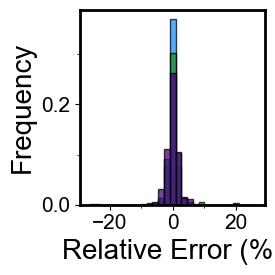

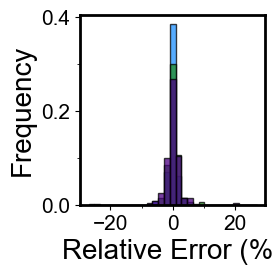

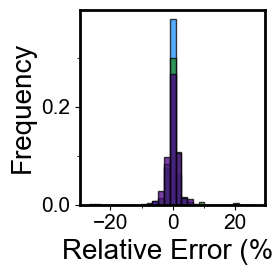

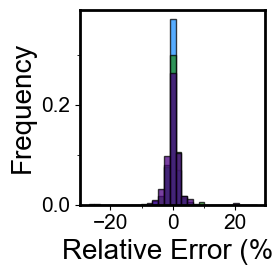

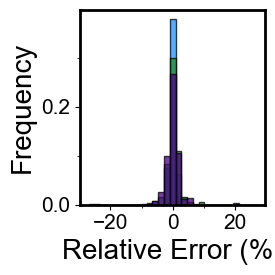

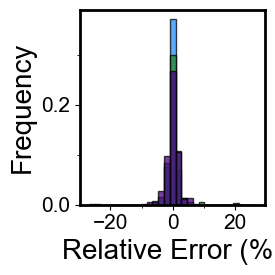

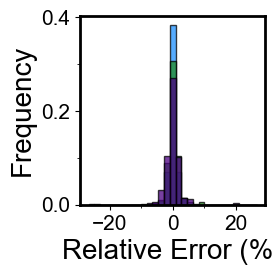

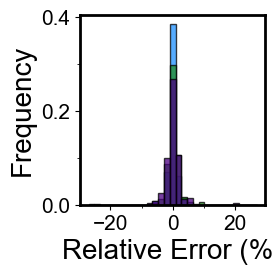

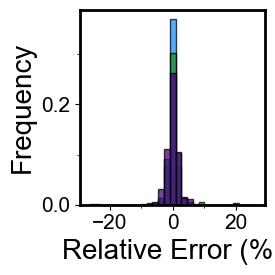

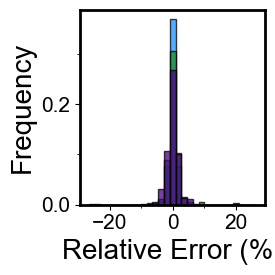

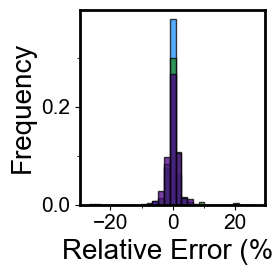

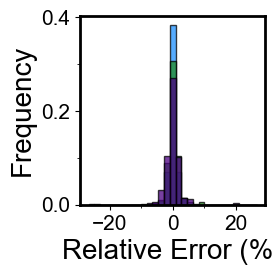

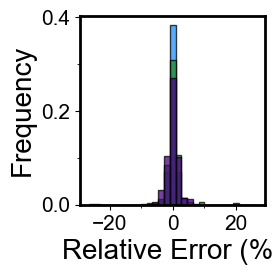

In [108]:
for name in smiles_maps:
    for method in similarity_methods:
        # Continuous descriptor methods cannot handle the wildcard present in the 'poly' SMILES
        if "poly" in name.lower() and method in ["rdkit_physchem", "mordred"]:
            continue
        
        df_likeness_key = f"{name}_{method}"
        df = df_likeness[df_likeness_key]
        # Drop rows with missing data
        df_clean = df.dropna()
        
        # Assign input variables and target variable
        inputs = df_clean.iloc[:, 1:50].copy()
        target = df_clean[f'{output}']
        
        # Split the data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            inputs, target, test_size=0.2, random_state=10
        )
        
        # Scale the inputs (fit only on training data to avoid data leakage)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
        X_test_scaled = scaler.transform(X_test)
        X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

        temp_model = best_models[df_likeness_key]
        
        X_all = pd.concat([X_train_scaled, X_test_scaled], ignore_index=True)
        y_all = np.concatenate([y_train, y_test])
        y_all_pred = temp_model.predict(X_all)
        
        print(f'\nModel trained on: {df_likeness_key}')

        plot_error_histogram(X_all, y_all, y_all_pred, df_likeness_key, output_path=f"./final_figs/{output}_scaled/error/")
                            # test_r2, df_likeness_key, output_path=f"./final_figs/{output}_scaled/")

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_residual_scatter(X_all, y_true, y_pred, method, output_path=None):
    # Compute residuals
    residuals = y_pred - y_true

    # Classify samples
    types_all = classify(X_all)
    colors = {'BCP': 'indigo', 'BCP+HP': 'dodgerblue', 'BCP+BCP': 'forestgreen'}

    # Create figure
    plt.figure(figsize=(8,6))

    # Scatter residuals vs actual values
    for label, color in colors.items():
        mask = types_all == label
        z = 0 if label == 'BCP+BCP' else 2
        plt.scatter(
            y_true[mask], residuals[mask],
            color=color,
            edgecolors='black',
            alpha=0.8,
            s=100,
            label=label,
            zorder=z
        )

    # Horizontal line at zero residual
    plt.axhline(0, color='red', linestyle='--', linewidth=2)

    plt.xlabel("Actual domain spacing (nm)", fontsize=18)
    plt.ylabel("Residuals (Predicted - Actual) [nm]", fontsize=18)
    plt.legend(fontsize=14, frameon=False)
    plt.grid(False)
    plt.tight_layout()

    if output_path:
        plt.savefig(f"{output_path}_{method}residual_scatter.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
    else:
        plt.show()

    # Optional metrics
    me = np.mean(residuals)
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    r2 = 1 - np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2)

    print(f"Mean Error (Bias): {me:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²: {r2:.3f}")



Model trained on: poly_morgan
Mean Error (Bias): 0.025
MAE: 0.430
RMSE: 0.707
R²: 0.994

Model trained on: poly_rdkit_path
Mean Error (Bias): 0.022
MAE: 0.428
RMSE: 0.700
R²: 0.994

Model trained on: poly_maccs
Mean Error (Bias): 0.023
MAE: 0.430
RMSE: 0.701
R²: 0.994

Model trained on: repeat_morgan
Mean Error (Bias): 0.024
MAE: 0.429
RMSE: 0.696
R²: 0.995

Model trained on: repeat_rdkit_path
Mean Error (Bias): 0.022
MAE: 0.428
RMSE: 0.697
R²: 0.994

Model trained on: repeat_maccs
Mean Error (Bias): 0.021
MAE: 0.429
RMSE: 0.699
R²: 0.994

Model trained on: repeat_rdkit_physchem
Mean Error (Bias): 0.021
MAE: 0.429
RMSE: 0.697
R²: 0.994

Model trained on: repeat_mordred
Mean Error (Bias): 0.021
MAE: 0.428
RMSE: 0.697
R²: 0.994

Model trained on: monomer_morgan
Mean Error (Bias): 0.025
MAE: 0.430
RMSE: 0.707
R²: 0.994

Model trained on: monomer_rdkit_path
Mean Error (Bias): 0.021
MAE: 0.428
RMSE: 0.698
R²: 0.994

Model trained on: monomer_maccs
Mean Error (Bias): 0.023
MAE: 0.430
RMSE: 

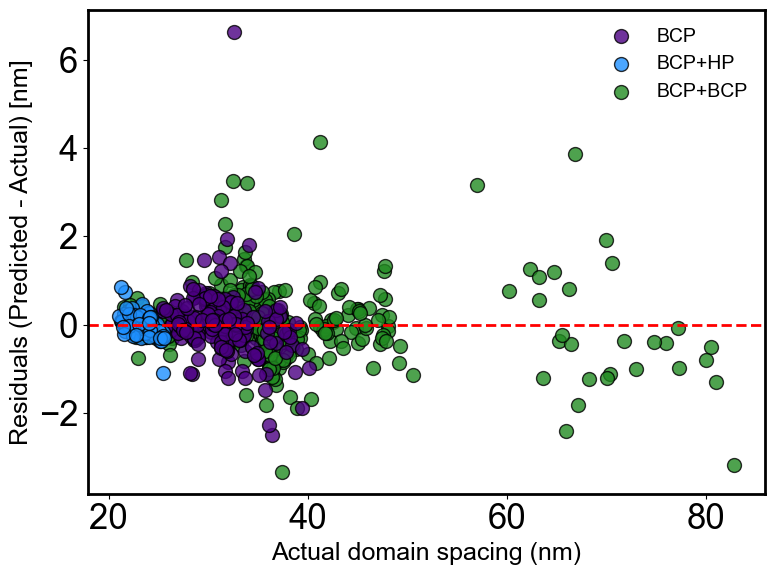

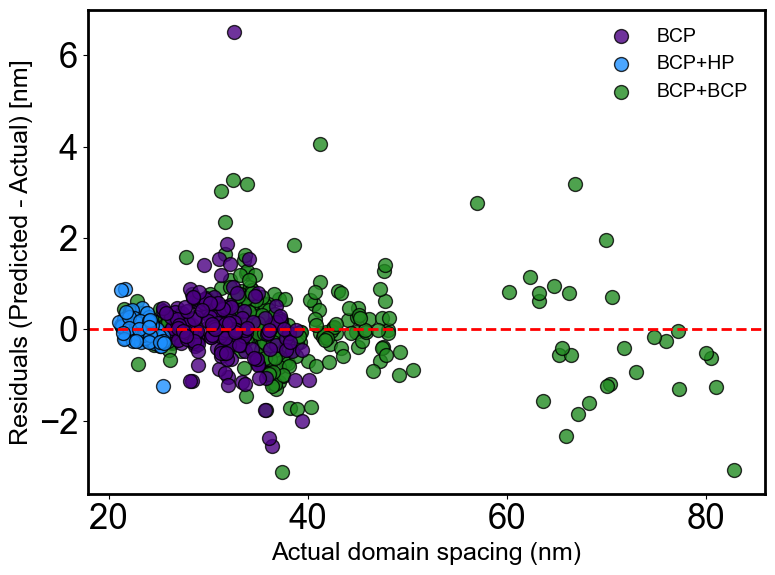

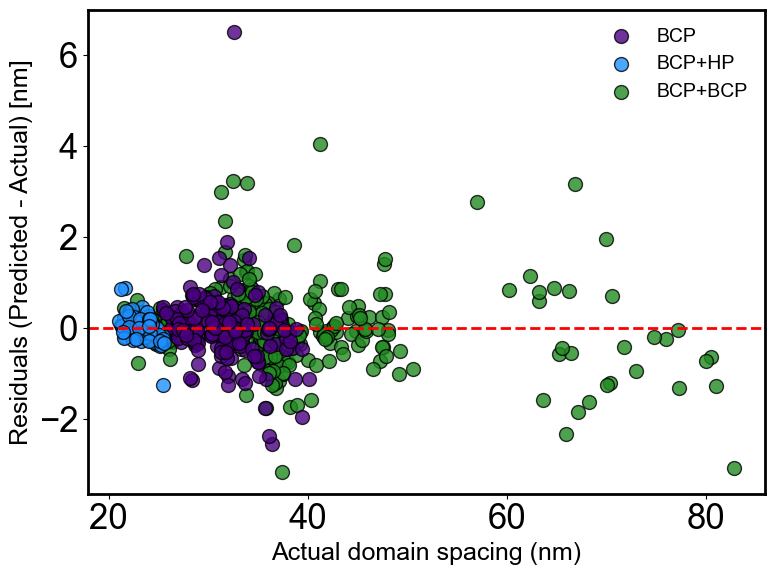

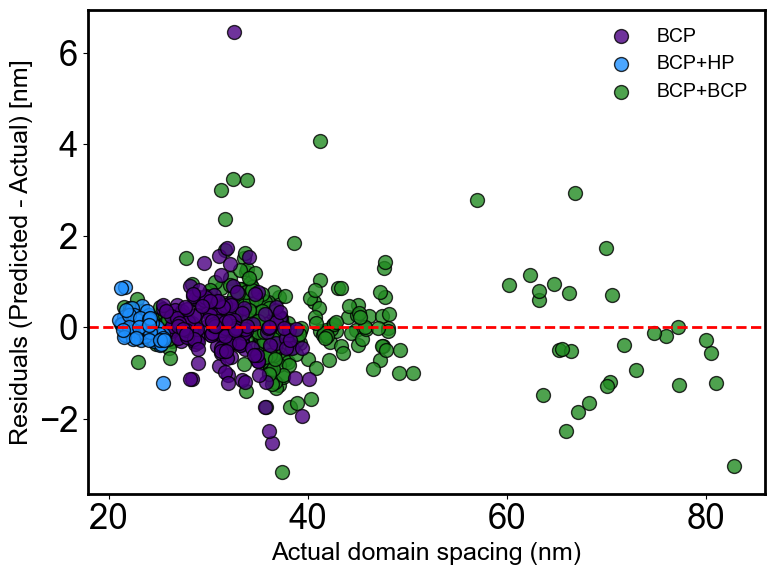

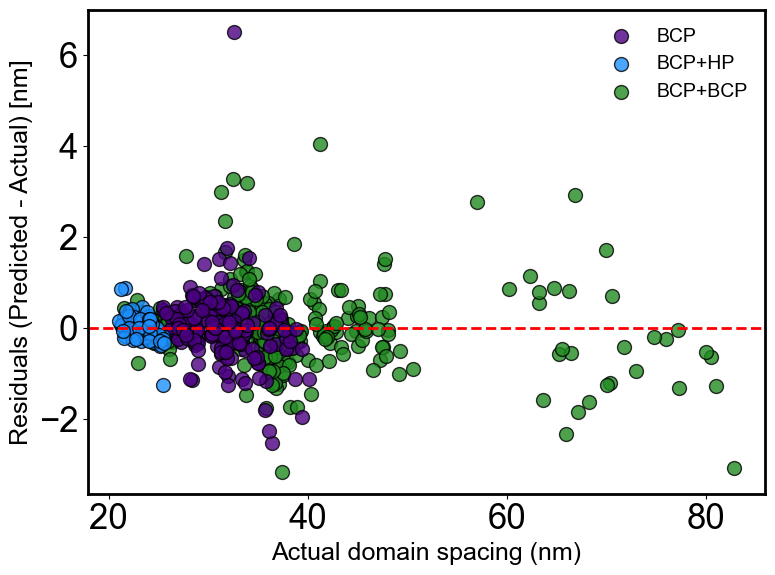

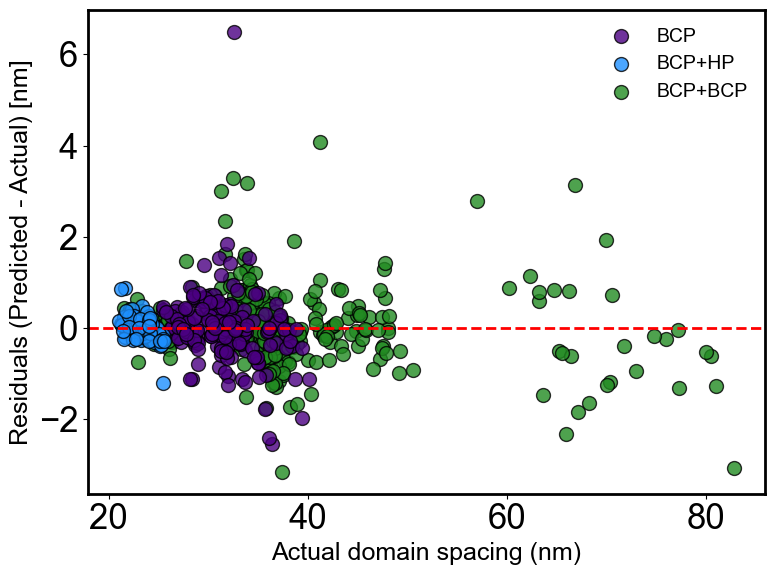

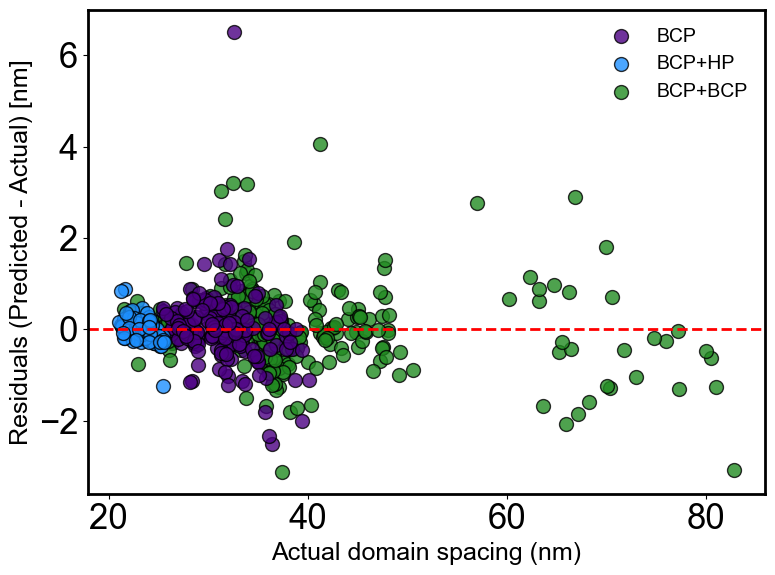

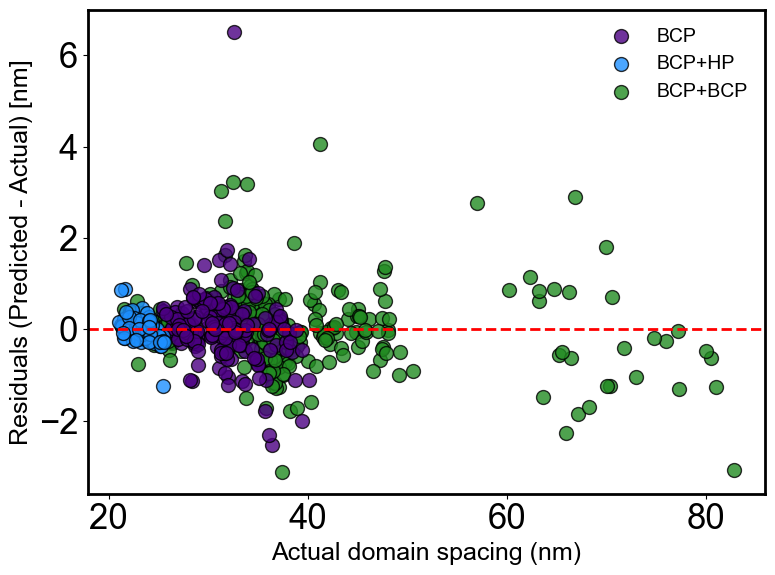

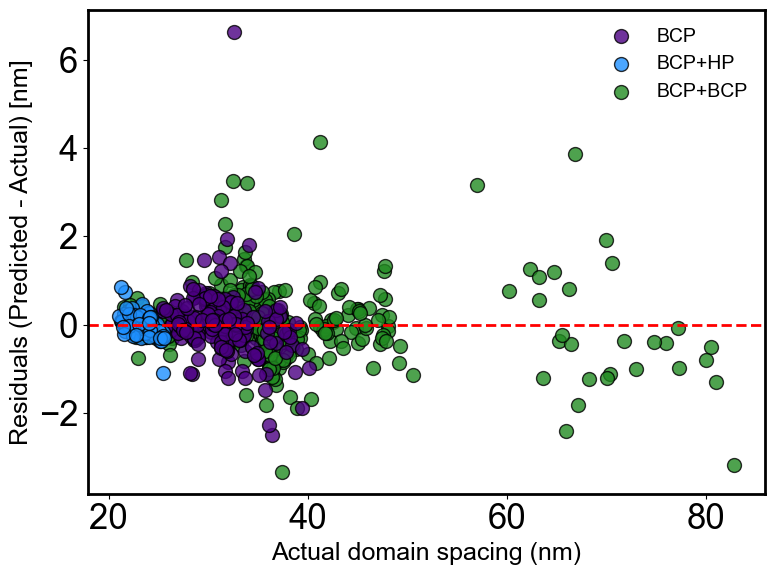

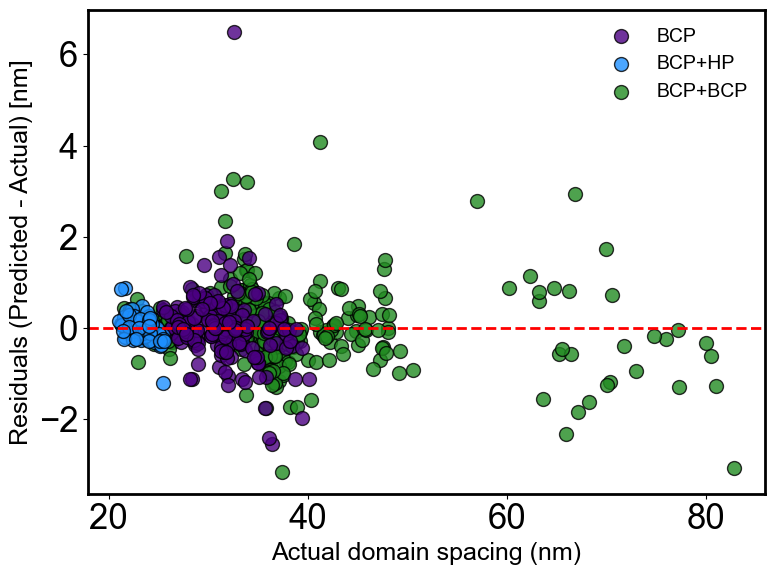

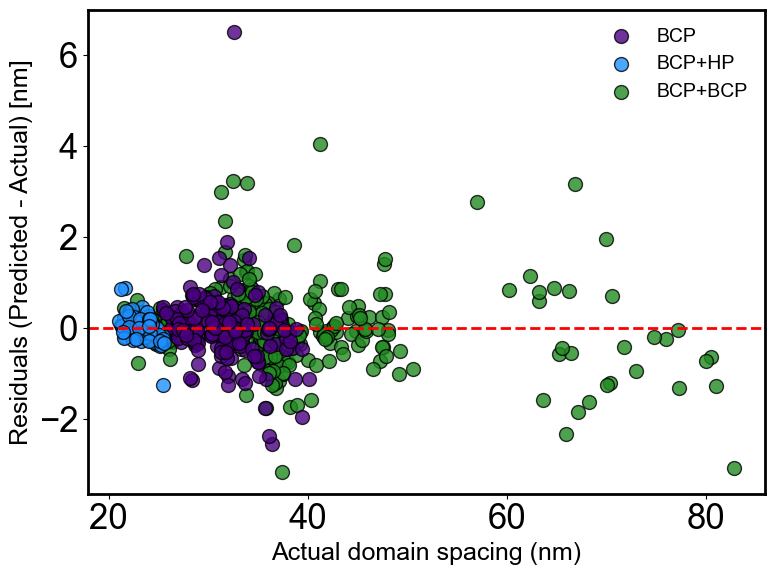

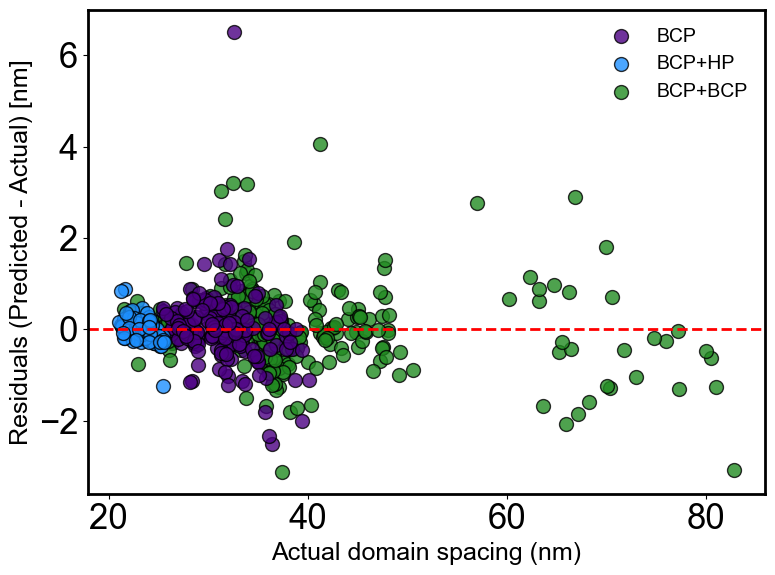

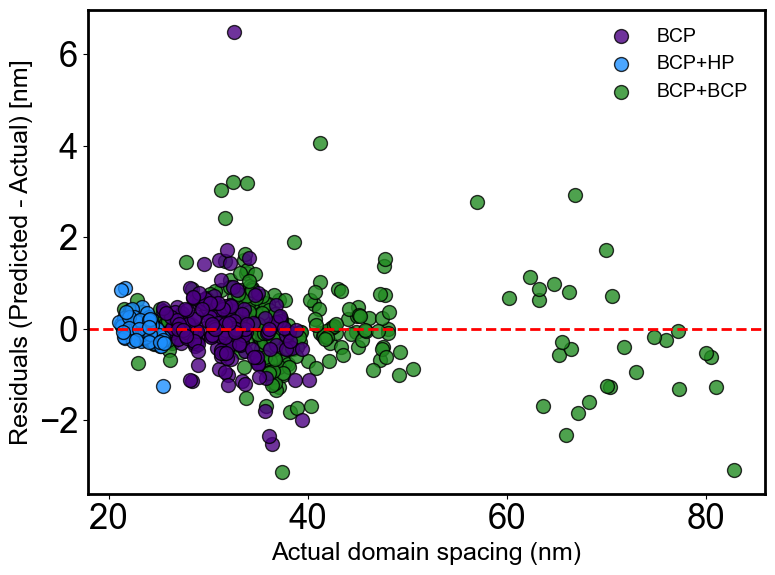

In [104]:
for name in smiles_maps:
    for method in similarity_methods:
        # Continuous descriptor methods cannot handle the wildcard present in the 'poly' SMILES
        if "poly" in name.lower() and method in ["rdkit_physchem", "mordred"]:
            continue
        
        df_likeness_key = f"{name}_{method}"
        df = df_likeness[df_likeness_key]
        # Drop rows with any NaN values
        df_clean = df.dropna()
        
        # Assign input variables and target variable
        inputs = df_clean.iloc[:, 1:50].copy()
        target = df_clean[f'gisaxs_domain']
        
        # Split the data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=10)

        temp_model = best_models[df_likeness_key]
        
        print(f'\nModel trained on: {df_likeness_key}')
        
        train_r2 = temp_model.score(X_train, y_train)
        test_r2 = temp_model.score(X_test, y_test)


        y_train_pred = temp_model.predict(X_train)
        y_test_pred = temp_model.predict(X_test)

        X_all = pd.concat([X_train, X_test], ignore_index=True)
        y_all = np.concatenate([y_train, y_test])
        y_all_pred = np.concatenate([y_train_pred, y_test_pred])

        # train_mae = mean_absolute_error(y_train, y_train_pred)
        # test_mae = mean_absolute_error(y_test, y_test_pred)

        # train_mae = mean_absolute_error(y_train, y_train_pred)
        # test_mae = mean_absolute_error(y_test, y_test_pred)
        
        # print(f'Training r2: {train_r2}, training mae: {train_mae}')
        # print(f'Testing r2: {test_r2}, testing mae: {test_mae}')

        plot_residual_scatter(X_all, y_all, y_all_pred, method, output_path=f"../final_figs/{output}/")

In [36]:
for name in smiles_maps:
    for method in similarity_methods:
        # Continuous descriptor methods cannot handle the wildcard present in the 'poly' SMILES
        if "poly" in name.lower() and method in ["rdkit_physchem", "mordred"]:
            continue
                
        # Store each df into a dictionary for access later
        df_likeness_key = f"{name}_{method}"        
        dump(best_models[df_likeness_key] , f'{output}_{df_likeness_key}.joblib')